### <h4 style="color:blue;">03 sample gambar</h5>

In [ ]:
# sample gambar train vs crop perbandingan per kelas
num_samples = 5

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 2.5 * len(classes)))
fig.suptitle('Sampel Gambar dari Setiap Kelas', fontsize=20, y=1.02)

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    
    if os.path.exists(class_path) and len(os.listdir(class_path)) > 0:
        all_images = os.listdir(class_path)
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(cls, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">04 file format check</h5>

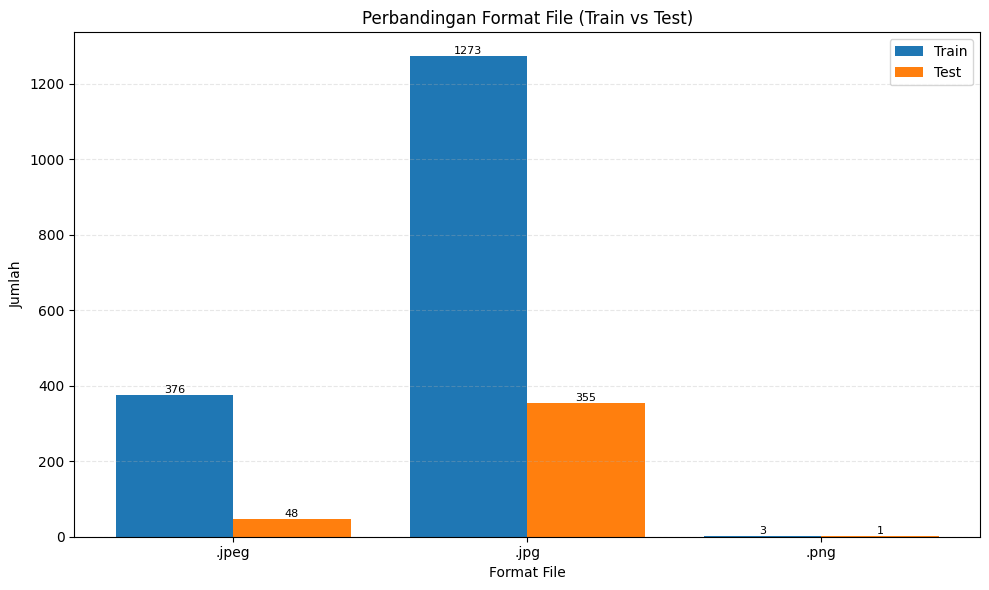

In [ ]:
# ada format apa aja?

def count_formats(directory):
    counter = Counter()
    
    for root, _, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext:  # skip kalau ga ada extension
                counter[ext] += 1
                
    return counter

# hitung
train_formats = count_formats(TRAIN_PATH)
test_formats  = count_formats(TEST_PATH)

all_formats = sorted(set(train_formats) | set(test_formats))

train_counts = [train_formats.get(f, 0) for f in all_formats]
test_counts  = [test_formats.get(f, 0) for f in all_formats]

x = range(len(all_formats))
width = 0.4

# plot
plt.figure(figsize=(10, 6))

bars1 = plt.bar([i - width/2 for i in x], train_counts, width, label='Train')
bars2 = plt.bar([i + width/2 for i in x], test_counts,  width, label='Test')

plt.xticks(x, all_formats)
plt.xlabel("Format File")
plt.ylabel("Jumlah")
plt.title("Perbandingan Format File (Train vs Test)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# label angka
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
fake = 222 + 278 + 118 + 228 + 338
real = 465

labels = [f'Fake ({fake})', f'Real ({real})']
sizes = [fake, real]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Fake vs Real Distribution')
plt.show()

print("Total rows:", 1184+465)


In [ ]:
def print_images_resolution(df):
    unique_sizes = set()
    total_images = len(df)

    # hitung jumlah per label (optional tapi bagus)
    print("Jumlah per label:")
    print(df['label'].value_counts())
    print("---------------")

    for img_path in df['image_path']:
        try:
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)  # (width, height)
        except Exception as e:
            print(f"Error baca: {img_path}")

    print("Unique resolutions:")
    for size in sorted(unique_sizes):
        print(f"- {size}")

    print("---------------")
    print(f"Total images: {total_images}")

print("\nChecking image resolutions in training set:")
print_images_resolution(df_train)

In [ ]:
base_path = "data/train"

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    
    if os.path.isdir(cls_path):
        shapes = []

        for file in os.listdir(cls_path):
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(cls_path, file)
                img = cv2.imread(img_path)
                
                if img is not None:
                    h, w = img.shape[:2]
                    shapes.append((h, w))

        shapes = pd.DataFrame(shapes, columns=['X', 'Y'])

        plt.figure(figsize=(10, 6))
        sns.kdeplot(shapes['X'], bw_adjust=0.5, label='Height (X)')
        sns.kdeplot(shapes['Y'], bw_adjust=0.5, label='Width (Y)')
        
        plt.title(f'Distribution of Image Sizes - {cls}')
        plt.legend()
        plt.show()

<h5 style="color:blue;">anomali dalam dataset

In [ ]:
VALID_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def scan_anomalies(base_path, is_train=True):
    bad_files = []
    total_files = 0

    if is_train:
        # ada class folder
        for class_name in os.listdir(base_path):
            class_path = os.path.join(base_path, class_name)

            if not os.path.isdir(class_path):
                continue

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                if not img_name.lower().endswith(VALID_EXT):
                    continue

                total_files += 1

                try:
                    img = Image.open(img_path)

                    # cek 1: bisa dibuka
                    img.verify()  # penting: detect corrupt

                    # buka ulang setelah verify
                    img = Image.open(img_path)

                    # cek 2: mode aneh
                    if img.mode not in ["RGB", "L"]:
                        bad_files.append((img_path, f"mode: {img.mode}"))
                        continue

                    # cek 3: ukuran aneh
                    if img.size[0] < 10 or img.size[1] < 10:
                        bad_files.append((img_path, f"too small: {img.size}"))
                        continue

                except Exception as e:
                    bad_files.append((img_path, "corrupt / unreadable"))

    else:
        # test biasanya tanpa class folder
        for img_name in os.listdir(base_path):
            img_path = os.path.join(base_path, img_name)

            if not img_name.lower().endswith(VALID_EXT):
                continue

            total_files += 1

            try:
                img = Image.open(img_path)
                img.verify()

                img = Image.open(img_path)

                if img.mode not in ["RGB", "L"]:
                    bad_files.append((img_path, f"mode: {img.mode}"))
                    continue

                if img.size[0] < 10 or img.size[1] < 10:
                    bad_files.append((img_path, f"too small: {img.size}"))
                    continue

            except Exception as e:
                bad_files.append((img_path, "corrupt / unreadable"))

    return total_files, bad_files


# ===== RUN =====
train_total, train_bad = scan_anomalies(TRAIN_PATH, is_train=True)
test_total, test_bad   = scan_anomalies(TEST_PATH, is_train=False)

# ===== PRINT =====
print("\n=== TRAIN ===")
print("Total files:", train_total)
print("Anomalies:", len(train_bad))

for path, reason in train_bad:
    print(f"[TRAIN] {reason} -> {path}")

print("\n=== TEST ===")
print("Total files:", test_total)
print("Anomalies:", len(test_bad))

for path, reason in test_bad:
    print(f"[TEST] {reason} -> {path}")


=== TRAIN ===
Total files: 1652
Anomalies: 2
[TRAIN] mode: RGBA -> ../data/train\fake_mannequin\mannequin_183.png
[TRAIN] mode: RGBA -> ../data/train\fake_unknown\unknown_283.png

=== TEST ===
Total files: 404
Anomalies: 1
[TEST] mode: P -> ../data/test\test_197.png


<h5 style="color:blue;">distribusi image size

Missing size rows: 0
               count         mean          std     min        5%       25%  \
width         2056.0  1073.772374   877.139679  168.00  256.0000  360.0000   
height        2056.0  1534.442121  1253.444821  183.00  256.0000  480.0000   
aspect_ratio  2056.0     0.789227     0.243680    0.33    0.5625    0.5625   

                  50%     75%          95%          max  
width          959.00  1280.0  3024.000000  5664.000000  
height        1280.00  1920.0  3840.000000  6528.000000  
aspect_ratio     0.75     1.0     1.333333     2.113208  


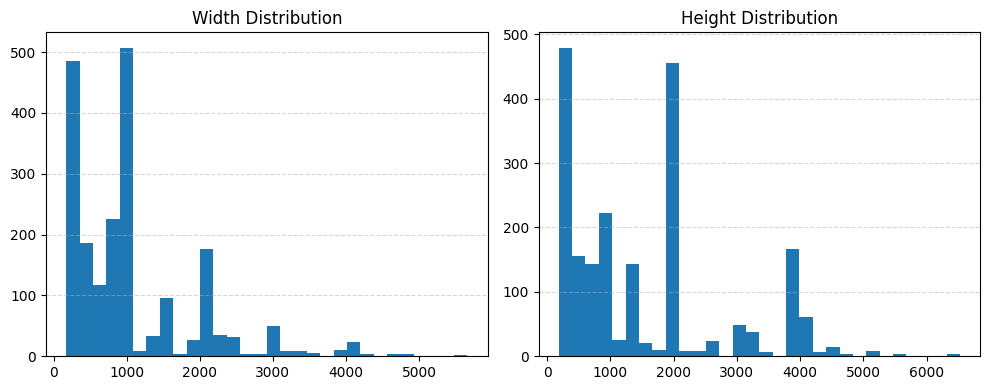

In [ ]:
def collect_files(base_path, is_train=True):
    data = []

    if is_train:
        for cls in os.listdir(base_path):
            cls_path = os.path.join(base_path, cls)
            if not os.path.isdir(cls_path):
                continue

            for f in os.listdir(cls_path):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    data.append(os.path.join(cls_path, f))
    else:
        for f in os.listdir(base_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append(os.path.join(base_path, f))

    return data

# gabung train + test
all_files = collect_files(TRAIN_PATH, True) + collect_files(TEST_PATH, False)

all_df = pd.DataFrame({"file_path": all_files})

# ===== ambil size =====
def read_size(path):
    try:
        with Image.open(path) as img:
            return img.size
    except:
        return np.nan, np.nan

size_df = all_df.copy()

size_df[["width", "height"]] = size_df["file_path"].apply(
    lambda p: pd.Series(read_size(p))
)

size_df["aspect_ratio"] = size_df["width"] / size_df["height"]

# ===== info =====
print("Missing size rows:", int(size_df["width"].isna().sum()))

print(
    size_df[["width", "height", "aspect_ratio"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)

# ===== plot =====
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(size_df["width"].dropna(), bins=30)
plt.title("Width Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(size_df["height"].dropna(), bins=30)
plt.title("Height Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
widths = []
heights = []

# Mengambil sampel maksimal 500 gambar per kelas agar proses tidak terlalu lama
for cls in classes:
    class_path = os.path.join(OUTPUT_DIR, cls)
    image_files = glob.glob(os.path.join(class_path, '*.*'))[:500]
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            pass

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.3, color='blue')
plt.title('Sebaran Resolusi Gambar Cropped (Lebar vs Tinggi)')
plt.xlabel('Lebar (Pixels)')
plt.ylabel('Tinggi (Pixels)')
plt.grid(True)
plt.show()

print(f"Rata-rata Lebar: {np.mean(widths):.2f} pixels")
print(f"Rata-rata Tinggi: {np.mean(heights):.2f} pixels")

In [ ]:
train_widths = []
train_heights = []

# Mengambil sampel gambar dari folder train (maksimal 500 gambar agar cepat)
train_image_files = glob.glob(os.path.join(TRAIN_DIR, '*.*'))[:500]

for img_path in train_image_files:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            train_widths.append(w)
            train_heights.append(h)
    except:
        pass

# Visualisasi
plt.figure(figsize=(10, 6))
plt.scatter(train_widths, train_heights, alpha=0.5, color='orange', marker='s')
plt.title('Sebaran Resolusi Gambar Asli / Belum di-Crop (Folder Train)')
plt.xlabel('Lebar (Pixels)')
plt.ylabel('Tinggi (Pixels)')
plt.grid(True)
plt.show()

# Menampilkan statistik singkat
if len(train_widths) > 0:
    print(f"Total Sampel Dianalisis: {len(train_widths)} gambar")
    print(f"Rata-rata Lebar: {np.mean(train_widths):.2f} pixels")
    print(f"Rata-rata Tinggi: {np.mean(train_heights):.2f} pixels")
    print(f"Resolusi Terkecil: {min(train_widths)} x {min(train_heights)}")
    print(f"Resolusi Terbesar: {max(train_widths)} x {max(train_heights)}")
else:
    print("Tidak ada gambar yang berhasil dianalisis di folder train.")

In [ ]:
plt.figure(figsize=(12, 7))

# Plot gambar asli (Train)
plt.scatter(train_widths, train_heights, alpha=0.5, color='orange', label='Train (Original)')

# Plot gambar cropped (Output)
plt.scatter(widths, heights, alpha=0.5, color='blue', label='Output (Cropped Face)')

plt.title('Perbandingan Resolusi Gambar: Asli vs Cropped Face', fontsize=14)
plt.xlabel('Lebar (Pixels)', fontsize=12)
plt.ylabel('Tinggi (Pixels)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_brightness_contrast(image_paths, max_samples=500):
    brightness = []
    contrast = []
    
    for img_path in image_paths[:max_samples]:
        img = cv2.imread(img_path)
        if img is not None:
            # Ubah ke grayscale untuk kemudahan perhitungan intensitas cahaya
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness.append(np.mean(gray))
            contrast.append(np.std(gray))
            
    return brightness, contrast

# Mengumpulkan sampel path untuk folder output (gabungan semua kelas)
output_image_files = []
for cls in classes:
    output_image_files.extend(glob.glob(os.path.join(OUTPUT_DIR, cls, '*.*'))[:100]) # Ambil 100 per kelas agar adil

# Menghitung metrik
train_b, train_c = get_brightness_contrast(train_image_files)
out_b, out_c = get_brightness_contrast(output_image_files)

print(f"Rata-rata Kecerahan (Train): {np.mean(train_b):.2f}")
print(f"Rata-rata Kecerahan (Output): {np.mean(out_b):.2f}")
print(f"Rata-rata Kontras (Train): {np.mean(train_c):.2f}")
print(f"Rata-rata Kontras (Output): {np.mean(out_c):.2f}")

# Visualisasi Scatter Plot Kecerahan vs Kontras
plt.figure(figsize=(12, 7))
plt.scatter(train_b, train_c, alpha=0.5, color='orange', label='Train (Original Image)')
plt.scatter(out_b, out_c, alpha=0.5, color='blue', label='Output (Cropped Face)')

plt.title('Sebaran Kecerahan vs Kontras: Original vs Cropped', fontsize=14)
plt.xlabel('Kecerahan (Mean Pixel Intensity)')
plt.ylabel('Kontras (Std Dev Pixel Intensity)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_average_rgb_histogram(image_paths, max_samples=300):
    avg_hist = np.zeros((256, 3)) # 256 bins, 3 channels
    valid_count = 0
    
    for img_path in image_paths[:max_samples]:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            for i in range(3): # 0:R, 1:G, 2:B
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                avg_hist[:, i] += hist.flatten()
            valid_count += 1
            
    if valid_count > 0:
        avg_hist /= valid_count # Rata-rata
        # Normalisasi ke skala 0-1 untuk perbandingan
        for i in range(3):
            if np.sum(avg_hist[:, i]) > 0:
                avg_hist[:, i] /= np.sum(avg_hist[:, i])
                
    return avg_hist

# Menghitung histogram
hist_train = get_average_rgb_histogram(train_image_files)
hist_out = get_average_rgb_histogram(output_image_files)

# Visualisasi Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ('red', 'green', 'blue')

# Plot Train
for i, col in enumerate(colors):
    axes[0].plot(hist_train[:, i], color=col, label=f'{col.capitalize()} channel')
axes[0].set_title('Rata-rata Distribusi RGB (Train / Original)')
axes[0].set_xlabel('Nilai Pixel (0-255)')
axes[0].set_ylabel('Frekuensi Relatif')
axes[0].legend()

# Plot Output
for i, col in enumerate(colors):
    axes[1].plot(hist_out[:, i], color=col, label=f'{col.capitalize()} channel')
axes[1].set_title('Rata-rata Distribusi RGB (Output / Cropped Face)')
axes[1].set_xlabel('Nilai Pixel (0-255)')
axes[1].set_ylabel('Frekuensi Relatif')
axes[1].legend()

plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

# Warna berbeda untuk setiap kelas
palette = sns.color_palette("hsv", len(classes))

for idx, cls in enumerate(classes):
    cls_paths = glob.glob(os.path.join(OUTPUT_DIR, cls, '*.*'))[:150]
    b, c = get_brightness_contrast(cls_paths)
    
    # Jika kelas adalah realperson, buat lebih tebal/berbeda agar mudah dianalisis
    if cls == 'realperson':
        plt.scatter(b, c, alpha=0.8, color='black', marker='*', s=150, label=f'{cls} (REAL)')
    else:
        plt.scatter(b, c, alpha=0.5, color=palette[idx], label=f'{cls}')

plt.title('Pemetaan Brightness vs Contrast antar Kelas Wajah (Real vs Fake)', fontsize=15)
plt.xlabel('Kecerahan (Mean)')
plt.ylabel('Kontras (Std Dev)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

<h5 style="color:blue;">data duplikat

In [ ]:
def file_md5(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hash_df = all_df[["split", "label", "file_name", "file_path"]].copy()
hash_df["md5"] = hash_df["file_path"].apply(file_md5)

dup_all = hash_df[hash_df.duplicated(subset=["md5"], keep=False)].sort_values("md5")
dup_train = hash_df[(hash_df["split"] == "train") & hash_df.duplicated(subset=["md5"], keep=False)].sort_values("md5")

train_hashes = set(hash_df.loc[hash_df["split"] == "train", "md5"])
test_hashes = set(hash_df.loc[hash_df["split"] == "test", "md5"])
cross_overlap = len(train_hashes.intersection(test_hashes))

print(f"Duplicate rows (all): {len(dup_all)}")
print(f"Duplicate rows (train): {len(dup_train)}")
print(f"Train-Test exact hash overlap: {cross_overlap}")
display(dup_all.head(20))

<h5 style="color:blue;">distribusi jumlah foto per kelas

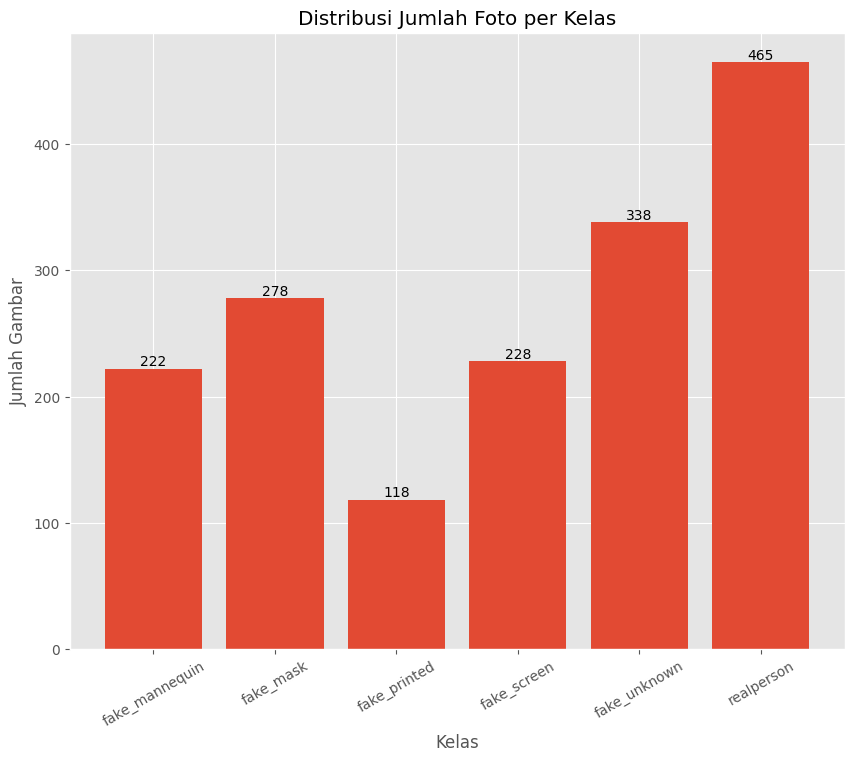

In [ ]:

# optional: kalau mau fix urutan class
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

nimgs = {}

for cls in classes:
    cls_path = os.path.join(base_path, cls)

    if not os.path.exists(cls_path):
        print(f"Warning: {cls_path} tidak ditemukan")
        nimgs[cls] = 0
        continue

    files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    nimgs[cls] = len(files)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(nimgs)), list(nimgs.values()))

plt.xticks(range(len(nimgs)), list(nimgs.keys()), rotation=30)
plt.title('Distribusi Jumlah Foto per Kelas')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kelas')

# kasih label angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt

# base path
TRAIN_PATH = "./data/train"

# optional: fix urutan class
classes = [
    'realperson',
    'fake_mask',
    'fake_printed',
    'fake_screen',
    'fake_mannequin',
    'fake_unknown'
]

def count_images_per_class(base_path, classes=None):
    nimgs = {}

    # kalau class tidak diset → auto detect
    if classes is None:
        classes = [
            d for d in os.listdir(base_path)
            if os.path.isdir(os.path.join(base_path, d))
        ]

    for cls in classes:
        cls_path = os.path.join(base_path, cls)

        if not os.path.exists(cls_path):
            print(f"Warning: {cls_path} tidak ditemukan")
            nimgs[cls] = 0
            continue

        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
        ]

        nimgs[cls] = len(files)

    return nimgs


# hitung
nimgs = count_images_per_class(TRAIN_PATH, classes)

# plot
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(nimgs)), list(nimgs.values()))

plt.xticks(range(len(nimgs)), list(nimgs.keys()), rotation=30)
plt.title('Distribusi Jumlah Foto per Kelas')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kelas')

# label angka
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
# sample gambar tiap kelas

num_samples = 5

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 2.5 * len(classes)))
fig.suptitle('Sampel Gambar dari Setiap Kelas', fontsize=20, y=1.02)

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    
    if os.path.exists(class_path) and len(os.listdir(class_path)) > 0:
        all_images = os.listdir(class_path)
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(cls, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.show()